# Exploración Inicial de Datos (EDA)

## Objetivo
Realizar una exploración inicial del dataset para comprender su estructura,
detectar problemas de calidad de datos y definir los pasos de limpieza y transformación.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

In [15]:
DATA_PATH = "../data/raw/iris-dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [16]:
print("Shape:", df.shape)
df.info()

Shape: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [17]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,150.0,NaN,NaN,NaN,75.5,43.445368,1.0,38.25,75.5,112.75,150.0
SepalLengthCm,150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
SepalWidthCm,150.0,NaN,NaN,NaN,3.054,0.433594,2.0,2.8,3.0,3.3,4.4
PetalLengthCm,150.0,NaN,NaN,NaN,3.758667,1.76442,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,NaN,NaN,NaN,1.198667,0.763161,0.1,0.3,1.3,1.8,2.5
Species,150,3,Iris-setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [19]:
(nulls / len(df) * 100).round(2)

Id               0.0
SepalLengthCm    0.0
SepalWidthCm     0.0
PetalLengthCm    0.0
PetalWidthCm     0.0
Species          0.0
dtype: float64

In [21]:
df.duplicated().sum()

0

In [22]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

numerical_cols, categorical_cols


(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
 ['Species'])

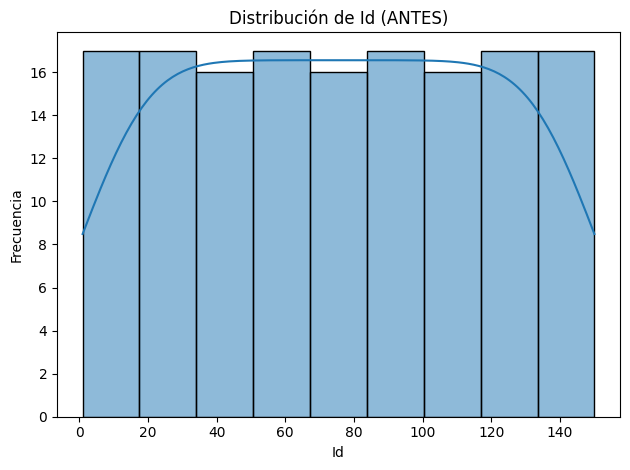

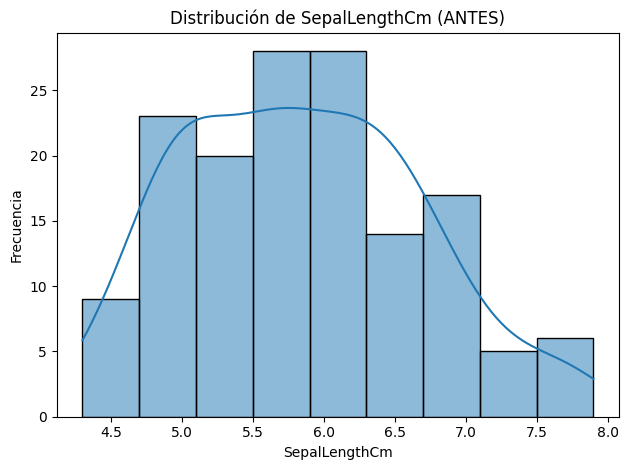

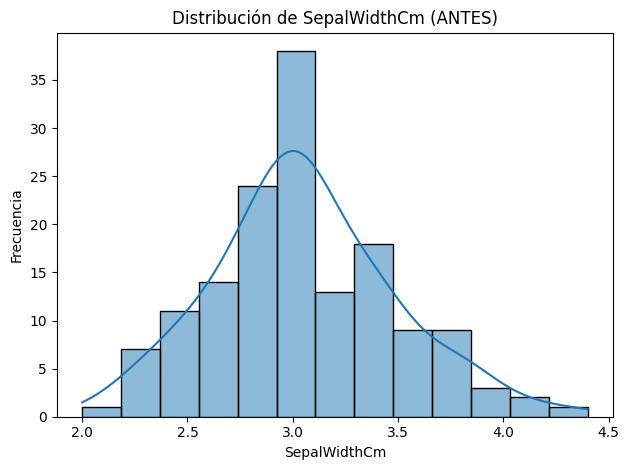

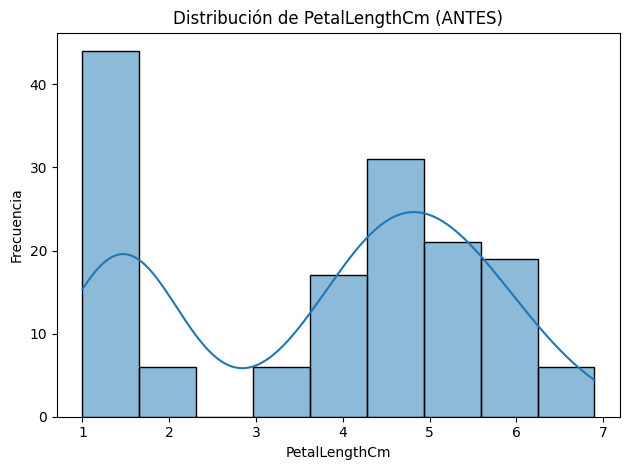

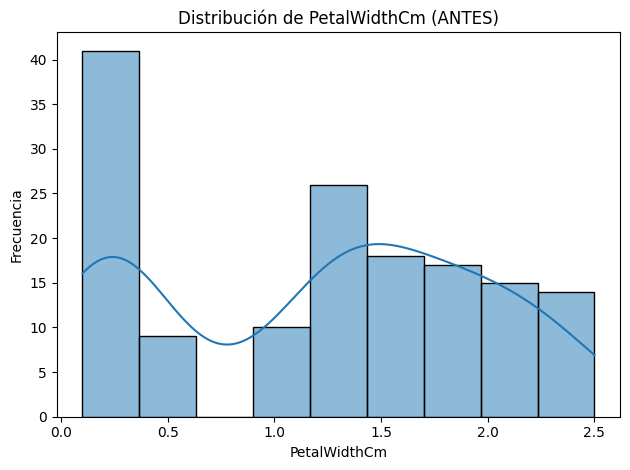

In [23]:
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde = True)
    plt.title(f"Distribución de {col} (ANTES)")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/hist_{col}.png")
    plt.show()

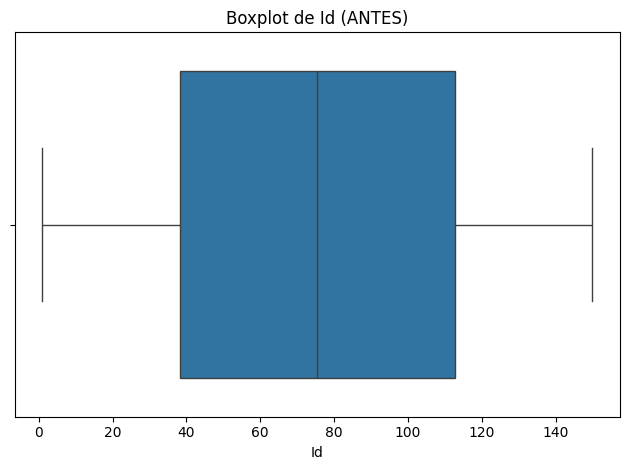

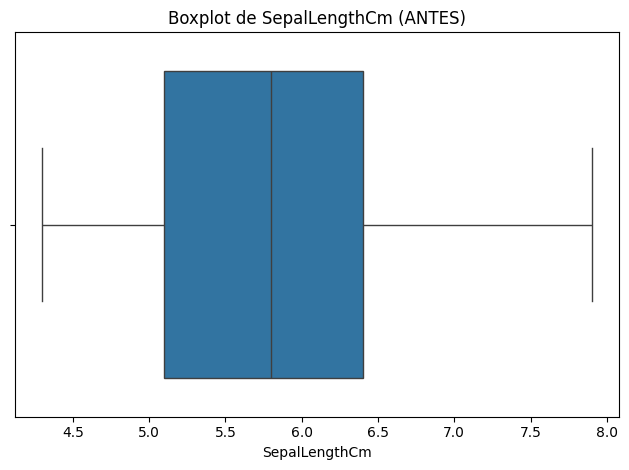

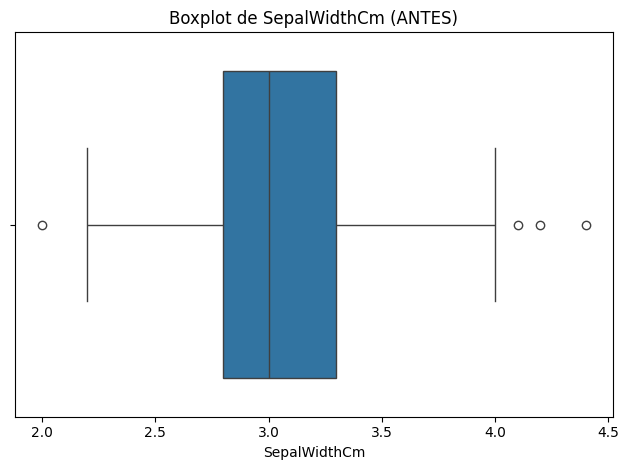

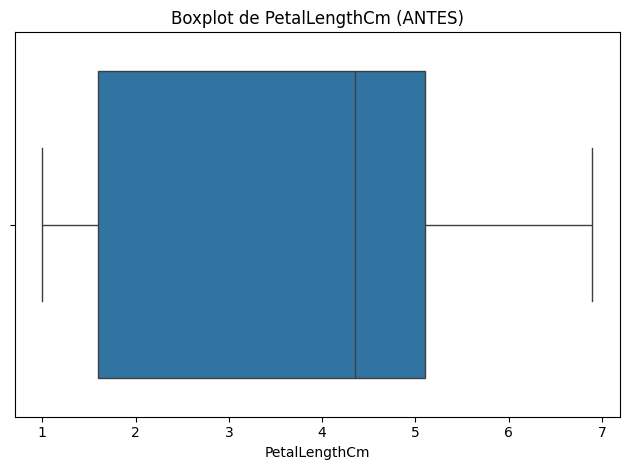

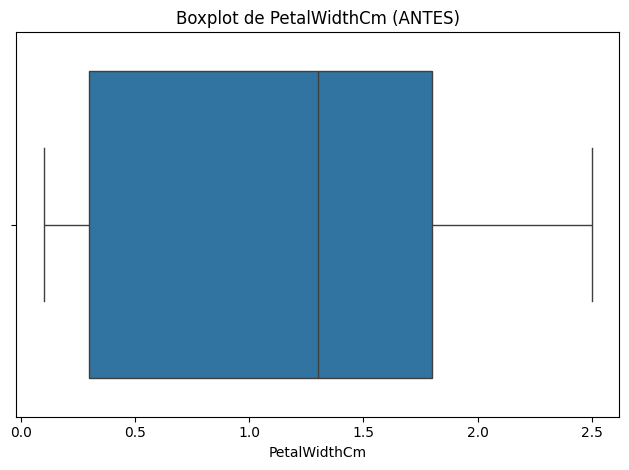

In [24]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col} (ANTES)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(f"../reports/figures/box_{col}.png")
    plt.show()

Visualizaciones BEFORE

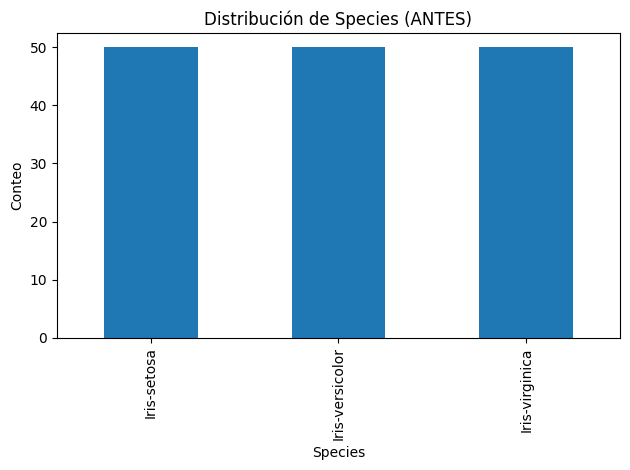

In [25]:
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col} (ANTES)")
    plt.xlabel(col)
    plt.ylabel("Conteo")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/before/count_{col}.png")
    plt.show()


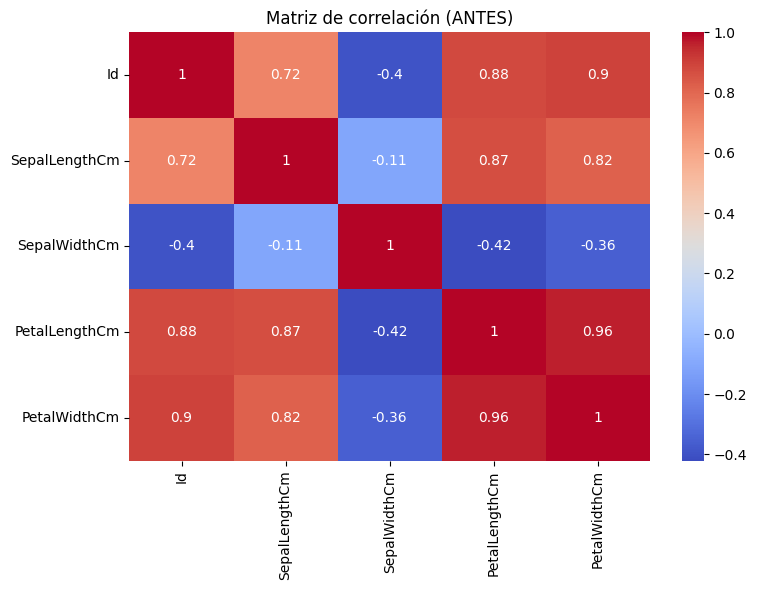

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación (ANTES)")
plt.tight_layout()
plt.savefig("../reports/figures/before/correlation.png")
plt.show()


## Conclusiones de la exploración
- Se identifican valores nulos en algunas variables que requerirán tratamiento.
- Existen outliers en variables numéricas que podrían afectar el análisis.
- Los tipos de datos y distribuciones justifican un proceso de limpieza y transformación.
- Los gráficos BEFORE permiten comparar el impacto del proceso ETL en la siguiente etapa.
